# Hands-On Agentic GraphRAG
## Notebook 5: Evaluation Harness

---
**Workshop series:** GraphRAG for Autonomous Incident Investigation

**Prerequisites:**
- Notebook 1: Vector RAG Concepts
- Notebook 2: Introduction to Knowledge Graphs (run the export cell to generate `incident_knowledge_graph.graphml`)
- Notebook 3: GraphRAG Concepts
- Notebook 4: Autonomous Incident Commander (run fully before this notebook)

**Runtime:** Google Colab — CPU

---

## Introduction

Across notebooks 1–4 we built a complete **Agentic GraphRAG** system:

| Notebook | What we built |
|---|---|
| 1 — Vector RAG | Embed-and-retrieve: find the most similar graph nodes |
| 2 — Knowledge Graph | Model your domain as entities connected by typed edges |
| 3 — GraphRAG Hybrid | Seed from vector search, then traverse the graph for richer context |
| 4 — Autonomous Agent | THINK → select the right skill → EXECUTE the tool → ANSWER |

Building a system is only the first step. **Before you can trust it in production you need
to measure it** — and you need to know that it stays correct when the world changes.

This notebook builds our **evaluation pipeline**: a repeatable harness that runs our AI
agent and two simpler baselines against a fixed challenge set and scores every answer.

### Two things we prove

**Part A — Who wins and why**
We run all three systems on the same five questions and compare keyword coverage scores.
This tells us which retrieval strategy is actually worth the added complexity.

**Part B — The system adapts without breaking**
A new incident (`INC-004`) arrives. We inject it into the **live graph
and vector store — no rebuild, no retraining, no code changes** — then re-run the *exact
same evaluation pipeline* on the *exact same five questions*.
If scores hold or improve, we have confidence the system is production-ready.
If any score drops, we have a regression and we know before it reaches users.

> Think of this notebook as the **QA pipeline for our autonomous agent**.
> It does not replace monitoring, but it is the first gate before any knowledge-base update
> goes live.

---

## Load the RAG Systems

Rather than re-implementing everything, we use Jupyter's `%run` magic to execute
`rag_systems.py` in the current kernel. After it completes, all names are live here.

> **Before running this cell** make sure:
> - `incident_knowledge_graph.graphml` is present (export it from Notebook 2)
> - `rag_systems.py` is in the same directory as this notebook

| Name available after `%run` | What it is |
|---|---|
| `chat_model` | Gemini, temperature 0.1 |
| `G` | NetworkX DiGraph — the full incident knowledge graph loaded from `incident_knowledge_graph.graphml` |
| `vector_store` | `InMemoryVectorStore` — every node summary embedded with HuggingFace BGE |
| `vector_rag(query)` | Vector search → LLM answer (no graph, no memory) |
| `graph_rag(query)` | BFS traversal from seeded nodes → LLM answer |
| `run(query)` | Full agentic loop with episodic memory: RECALL → THINK → EXECUTE → ANSWER → LOG |
| `memory` | `EpisodicMemory` instance — persists episodes to `episodic_memory.graphml` between runs |

This is exactly how you would load a component in production: the systems are defined once
and imported wherever they are needed — the notebook is just the entry point.

In [ ]:
import pathlib
import shutil
import urllib.request

REPO_RAW_BASE = "https://raw.githubusercontent.com/AmmarMohanna/oreilly-agentic-graphrag/main"


def ensure_repo_asset(source_path, local_path=None):
    """Make a repo asset available in the current runtime.

    Works in Colab when only the notebook was opened, and also works from a
    local checkout when the companion files are already beside the notebook.
    """
    source = pathlib.Path(source_path)
    target = pathlib.Path(local_path or source.name)

    if target.exists():
        print(f"Found {target}")
        return target

    local_candidates = [
        source,
        pathlib.Path.cwd() / source.name,
        pathlib.Path.cwd() / source,
        pathlib.Path.cwd().parent / source,
    ]
    for candidate in local_candidates:
        if candidate.exists():
            shutil.copy(candidate, target)
            print(f"Copied {candidate} -> {target}")
            return target

    url = f"{REPO_RAW_BASE}/{source_path}"
    print(f"Downloading {url}")
    urllib.request.urlretrieve(url, target)
    print(f"Saved {target}")
    return target

ensure_repo_asset("5.Hardening_Production/rag_systems.py", "rag_systems.py")
ensure_repo_asset(
    "5.Hardening_Production/incident_knowledge_graph.graphml.xml",
    "incident_knowledge_graph.graphml",
)
ensure_repo_asset(
    "5.Hardening_Production/episodic_memory.graphml.xml",
    "episodic_memory.graphml",
)
ensure_repo_asset("5.Hardening_Production/challenge_set.json", "challenge_set.json")
ensure_repo_asset("5.Hardening_Production/eval_results.json", "eval_results.json")

# Runs rag_systems.py in this kernel — brings in:
#   chat_model, G, vector_store
#   vector_rag(query)   — vector search -> LLM answer
#   graph_rag(query)    — BFS traversal -> LLM answer
#   run(query)          — agentic RAG with episodic memory
#   memory              — EpisodicMemory (persists between runs)
%run rag_systems.py


---

## Golden Questions

A **golden question set** is a fixed collection of questions with known expected answers.
Ours lives in `challenge_set.json` — a plain file you can edit without touching any
notebook code.

Each question carries a list of **expected keywords**: words a correct, grounded
answer must mention. The fraction found is the **keyword coverage score** (0–1).

| Score | Meaning |
|---|---|
| 1.0 | Every expected keyword appeared — answer is likely correct |
| 0.5 | Half the keywords found — partial or vague answer |
| 0.0 | No keywords — hallucination or irrelevant answer |

Keyword scoring is intentionally simple — deterministic, free, and fast.
It does not catch fluency or hallucination, but it reliably catches *missing information*.
That is the failure mode we care most about in an SRE context.

In [ ]:
import json

with open('challenge_set.json') as f:
    CHALLENGE = json.load(f)

for q in CHALLENGE:
    print(f"{q['id']}  {q['category']:<12}  {q['query']}")

---

## The Three Systems
 we will load the systems that we have to compare the results on the golden questions

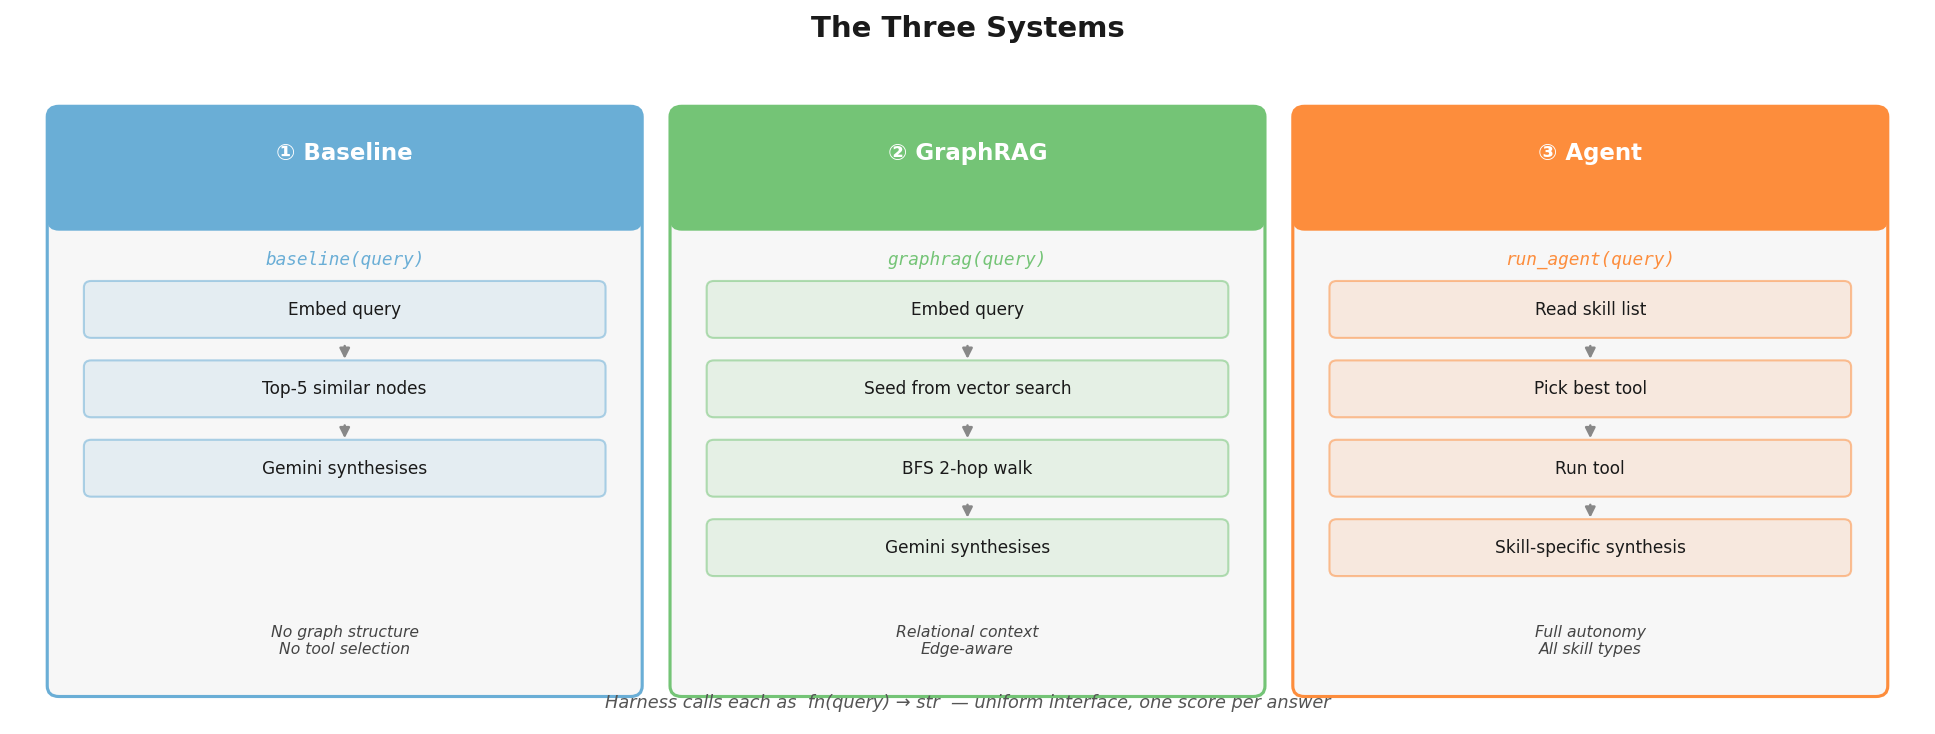

In [ ]:
# All three methods come directly from rag_systems.py — no re-implementation needed.
# vector_rag and graph_rag use a grounded LLM answer chain internally.
# run() adds THINK-based skill routing + episodic memory on top.

METHODS = {"vector_rag": vector_rag, "graph_rag": graph_rag, "agent": run}
print("Methods ready:", list(METHODS.keys()))

---

## Run the Evaluation

The harness iterates over every question in the challenge set, calls each system,
and records the keyword coverage score.
This will take a few seconds so you can directly load results.json in the next cell

Progress is printed per question so you can see which system is faster and spot any
API errors immediately rather than discovering them at the end.

In [ ]:
# import io, contextlib

# def keyword_score(answer, keywords):
#     a = answer.lower()
#     return round(sum(kw.lower() in a for kw in keywords) / len(keywords), 2)

# def run_regression(questions, label=""):
#     if label:
#         print(label)
#     rows = []
#     for q in questions:
#         print(f"{q['id']}  {q['query']}")
#         row = {"id": q["id"], "category": q["category"]}
#         for name, fn in METHODS.items():
#             with contextlib.redirect_stdout(io.StringIO()):  # silence verbose output
#                 ans = fn(q["query"])
#             ks  = keyword_score(ans, q["keywords"])
#             row[f"{name}_kw"]     = ks
#             row[f"{name}_answer"] = ans
#             print(f"  {name:<10}  {ks:.2f}")
#         rows.append(row)
#     return rows

# results = run_regression(CHALLENGE, label="Part A — Golden Questions")


---

## Results


In [ ]:
import json, pathlib
from datetime import datetime

METHOD_KEYS = list(METHODS.keys())

# Load previous results if they exist (allows re-running display without re-running eval)
_cache = pathlib.Path("eval_results.json")
if not results and _cache.exists():
    _loaded = json.loads(_cache.read_text())
    results = _loaded["results"]
    print(f"Loaded results from {_cache} (run_at: {_loaded['run_at']})")

header = f"{'ID':<4}  {'Category':<12}  " + "  ".join(f"{m:<10}" for m in METHOD_KEYS)
print(header)
print("-" * len(header))
for row in results:
    scores = "  ".join(f"{row[f'{m}_kw']:<10.2f}" for m in METHOD_KEYS)
    print(f"{row['id']:<4}  {row['category']:<12}  {scores}")

print()
for m in METHOD_KEYS:
    avg = sum(r[f"{m}_kw"] for r in results) / len(results)
    bar = chr(9608) * int(avg * 20)
    print(f"  {m:<10}  avg={avg:.2f}  {bar}")

# Save results to disk
out = {
    "run_at":  datetime.now().isoformat(timespec="seconds"),
    "label":   "Part A",
    "results": results,
}
with open("eval_results.json", "w") as f:
    json.dump(out, f, indent=2)
print("Saved -> eval_results.json")


---

## Part B — Live Knowledge Update + Regression Test

A production SRE system receives new incidents constantly. The critical question is:

> *When we add new knowledge, do the answers to existing questions stay correct?*

### What we are injecting

`INC-004` just came in.

We add four new nodes and four new edges to the live graph.

### How the update works — add, not replace

| Component | What happens |
|---|---|
| `G` (NetworkX graph) | `G.add_node()` and `G.add_edge()` — existing nodes/edges untouched |
| `run_agent()` | No change — it reads `G` and `vector_store` at call time, so it picks up the new data automatically |


After the injection we re-run the **same five questions** through the same evaluation
pipeline. The expected result: scores hold or improve. Any drop is a regression.

In [ ]:
import matplotlib.pyplot as plt
from langchain_core.documents import Document

# INC-004 — DB connection pool exhaustion.
# Only INC-004 and DEPLOY-007 are new; everything else already exists in the graph.
NEW_NODES = [
    ("INC-004",    "incident",   "Database connection pool exhausted. DEPLOY-007 cut db_pool_max from 100 to 20."),
    ("DEPLOY-007", "deployment", "Cache Service v2.0 config change — reduced db_pool_max 100 -> 20. Caused INC-004."),
]
NEW_EDGES = [
    ("INC-004",    "Database Service", "AFFECTS"),       # existing service
    ("INC-004",    "Cache Service",    "AFFECTS"),       # existing service
    ("INC-004",    "DEPLOY-007",       "TRIGGERED_BY"),
    ("DEPLOY-007", "Cache Service",    "DEPLOYED_TO"),   # existing service
    ("DEPLOY-007", "Data Engineering Team", "DEPLOYED_BY"), # existing team
]

for name, ntype, summary in NEW_NODES:
    G.add_node(name, name=name, type=ntype, summary=summary)
for src, dst, rel in NEW_EDGES:
    G.add_edge(src, dst, rel=rel)

vector_store.add_documents([
    Document(page_content=s, metadata={"name": n, "type": t})
    for n, t, s in NEW_NODES
])

print(f"Graph now: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


In [ ]:

# ── Draw the full updated graph ───────────────────────────────────────────────
new_node_ids = {n for n, _, _ in NEW_NODES}

TYPE_COLOR = {
    "incident":   "#e05252",
    "deployment": "#fd8d3c",
    "service":    "#6aaed6",
    "team":       "#74c476",
}

pos = nx.spring_layout(G, seed=42, k=2.0)
fig, ax = plt.subplots(figsize=(14, 9))

nx.draw_networkx_nodes(G, pos,
    node_color=[TYPE_COLOR.get(G.nodes[n].get("type",""), "#ccc") for n in G.nodes],
    node_size=[1200 if n in new_node_ids else 600 for n in G.nodes],
    edgecolors=["#000" if n in new_node_ids else "#555" for n in G.nodes],
    linewidths=[2.5 if n in new_node_ids else 1.0 for n in G.nodes],
    ax=ax)

nx.draw_networkx_labels(G, pos, font_size=7, font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos, edge_color="#888", arrows=True, arrowsize=15,
    width=1.2, ax=ax, connectionstyle="arc3,rad=0.05")
nx.draw_networkx_edge_labels(G, pos,
    edge_labels={(u,v): d.get("rel","") for u,v,d in G.edges(data=True)},
    font_size=6, ax=ax)

handles = [plt.matplotlib.patches.Patch(color=c, label=t) for t, c in TYPE_COLOR.items()]
handles.append(plt.matplotlib.patches.Patch(color="#ccc", label="other"))
ax.legend(handles=handles, loc="upper left", fontsize=8)
ax.set_title("Knowledge Graph after INC-004 injection — new nodes outlined in black",
             fontsize=11, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# Run Q2 from the challenge set — checks that incident queries still work after injection
results_after = run_regression([CHALLENGE[1]], label="Part B — After INC-004 injection")

In [ ]:
# Compare Q2 before vs after INC-004 injection
q_before = next(r for r in results       if r["id"] == CHALLENGE[1]["id"])
q_after  = results_after[0]

print(f"Part B — Before vs After INC-004 injection ({CHALLENGE[1]['query']})")
print(f"{'Method':<12}  {'Before':>8}  {'After':>8}  {'Delta':>8}")
print("-" * 44)
for m in METHOD_KEYS:
    b = q_before.get(f"{m}_kw", 0)
    a = q_after.get(f"{m}_kw", 0)
    flag = "  " if a >= b else "  ↓ REGRESSION"
    print(f"  {m:<10}  {b:>8.2f}  {a:>8.2f}  {a-b:>+8.2f}{flag}")

# Append Part B to eval_results.json
import json, pathlib
_cache = pathlib.Path("eval_results.json")
_data  = json.loads(_cache.read_text()) if _cache.exists() else {"label": "eval", "results": []}
_data["part_b"] = results_after
_cache.write_text(json.dumps(_data, indent=2))
print("Appended Part B -> eval_results.json")


### To Do: write a personal production checklist (what to log, what to monitor, what to test)

---

## Conclusion — From a Query to an Autonomous Agent

Over five notebooks we built a complete AI system from the ground up.

### What each notebook contributed

| Notebook | Component | Key idea |
|---|---|---|
| 1 — Vector RAG | Embed & retrieve | Represent knowledge as vectors; find similar items |
| 2 — Knowledge Graph | Graph construction | Model entities and relationships explicitly |
| 3 — GraphRAG | Hybrid retrieval | Combine semantic search with graph traversal |
| 4 — Autonomous Agent | Skills + Tools + Memory | Let the LLM choose the right retrieval strategy |
| 5 — Evaluation | Production readiness | Measure quality; prove updates don't break things |

### What we now have

An **autonomous SRE agent** that:

- Understands your knowledge graph — services, teams, incidents, deployments
- Selects the right tool per question type
- Adapts without retraining — new nodes land in the live graph immediately
- Can be evaluated and gated — the harness catches regressions before they ship

### What comes next

The system built here is a foundation. In a real production deployment you would add:

- **LLM-as-judge scoring** alongside keyword coverage for richer quality signals
- **Continuous graph ingestion** from your ticketing system, deployment pipeline, and APM
- **A/B evaluation** to compare agent versions before promoting to production
- **Latency and cost tracking** per skill so you can optimise the most expensive paths

But the core loop — *retrieve structured knowledge, select the right tool, synthesise
a grounded answer, evaluate before shipping* — is already here and working.